# 05 — `hilbert`: instantaneous phase & amplitude

`pha, amp = dsp.hilbert(x, dim=-1)` returns the analytic-signal
phase (radians) and amplitude envelope. Cross-checked against
`scipy.signal.hilbert`.

max|diff|/mean(ref): 7.115783091649064e-07


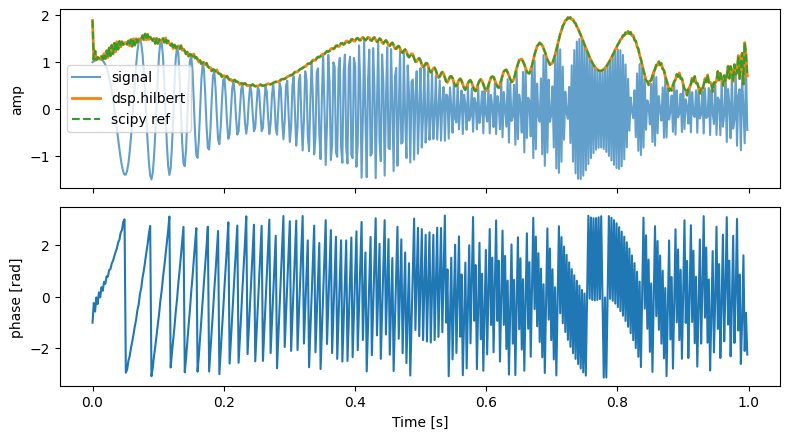

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert as scipy_hilbert
import scitex_dsp as dsp
%matplotlib inline

xx, tt, fs = dsp.demo_sig(sig_type="chirp", batch_size=1, n_chs=1,
                          t_sec=1, fs=512)
pha, amp = dsp.hilbert(xx)
pha, amp = np.asarray(pha), np.asarray(amp)
ref = np.abs(scipy_hilbert(np.asarray(xx)[0, 0]))

fig, ax = plt.subplots(2, 1, figsize=(8, 4.5), sharex=True)
ax[0].plot(tt, xx[0, 0], label="signal", alpha=0.7)
ax[0].plot(tt, amp[0, 0], label="dsp.hilbert", lw=2)
ax[0].plot(tt, ref, label="scipy ref", ls="--")
ax[0].legend(); ax[0].set_ylabel("amp")
ax[1].plot(tt, pha[0, 0]); ax[1].set_ylabel("phase [rad]")
ax[1].set_xlabel("Time [s]"); fig.tight_layout()
print("max|diff|/mean(ref):", float(np.max(np.abs(amp[0,0]-ref))/ref.mean()))
plt.show()
